In [2]:
import torch
import segmentation_models_pytorch as smp
from torchinfo import summary
from torchviz import make_dot
from torchview import draw_graph
from unet import UNet
from mlp import MLP
from mobileNet import MobileNet

In [3]:
unet = UNet(in_channels=3, num_classes=1, skip_connections=True)
pretrained = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", in_channels=3, classes=1)
mlp = MLP(input_size=3*28*28, hidden_sizes=[1024, 512, 64, 64], num_classes=9)
mobilenet = MobileNet(num_classes=9)

## torchinfo — Architecture Summary

In [3]:
print("=" * 80)
print("UNet (from scratch)")
print("=" * 80)
summary(unet, input_size=(1, 3, 512, 512), depth=3, col_names=["input_size", "output_size", "num_params", "kernel_size"])

UNet (from scratch)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
UNet                                     [1, 3, 512, 512]          [1, 1, 512, 512]          --                        --
├─Sequential: 1-1                        [1, 3, 512, 512]          [1, 64, 512, 512]         --                        --
│    └─Conv2d: 2-1                       [1, 3, 512, 512]          [1, 64, 512, 512]         1,792                     [3, 3]
│    └─ReLU: 2-2                         [1, 64, 512, 512]         [1, 64, 512, 512]         --                        --
│    └─Conv2d: 2-3                       [1, 64, 512, 512]         [1, 64, 512, 512]         36,928                    [3, 3]
│    └─ReLU: 2-4                         [1, 64, 512, 512]         [1, 64, 512, 512]         --                        --
├─MaxPool2d: 1-2                         [1, 64, 512, 512]         [1, 64, 256, 256]         --                        2
├─Seque

In [4]:
print("=" * 80)
print("Pretrained UNet (ResNet18 + ImageNet)")
print("=" * 80)
summary(pretrained, input_size=(1, 3, 512, 512), depth=4, col_names=["input_size", "output_size", "num_params", "kernel_size"])

Pretrained UNet (ResNet18 + ImageNet)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
Unet                                          [1, 3, 512, 512]          [1, 1, 512, 512]          --                        --
├─ResNetEncoder: 1-1                          [1, 3, 512, 512]          [1, 3, 512, 512]          --                        --
│    └─Conv2d: 2-1                            [1, 3, 512, 512]          [1, 64, 256, 256]         9,408                     [7, 7]
│    └─BatchNorm2d: 2-2                       [1, 64, 256, 256]         [1, 64, 256, 256]         128                       --
│    └─ReLU: 2-3                              [1, 64, 256, 256]         [1, 64, 256, 256]         --                        --
│    └─MaxPool2d: 2-4                         [1, 64, 256, 256]         [1, 64, 128, 128]         --                        3
│    └─Sequential: 2-5                        [1, 64, 128, 128]         [1, 64, 128, 128]         

In [24]:
print("=" * 80)
print("MLP")
print("=" * 80)
summary(mlp, input_size=(1, 3, 28, 28), depth=2, col_names=["input_size", "output_size", "num_params"])

MLP


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MLP                                      [1, 3, 28, 28]            [1, 9]                    --
├─ModuleList: 1-1                        --                        --                        --
│    └─Linear: 2-1                       [1, 2352]                 [1, 1024]                 2,409,472
│    └─Linear: 2-2                       [1, 1024]                 [1, 512]                  524,800
│    └─Linear: 2-3                       [1, 512]                  [1, 64]                   32,832
│    └─Linear: 2-4                       [1, 64]                   [1, 64]                   4,160
├─Linear: 1-2                            [1, 64]                   [1, 9]                    585
Total params: 2,971,849
Trainable params: 2,971,849
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.97
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 11.89
Estimat

In [25]:
print("=" * 80)
print("MobileNet")
print("=" * 80)
summary(mobilenet, input_size=(1, 3, 224, 224), depth=3, col_names=["input_size", "output_size", "num_params", "kernel_size"])

MobileNet


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
MobileNet                                [1, 3, 224, 224]          [1, 9]                    --                        --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 32, 112, 112]         864                       [3, 3]
│    └─BatchNorm2d: 2-2                  [1, 32, 112, 112]         [1, 32, 112, 112]         64                        --
│    └─ReLU: 2-3                         [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
├─DepthwiseSeparableConv: 1-2            [1, 32, 112, 112]         [1, 64, 112, 112]         --                        --
│    └─Conv2d: 2-4                       [1, 32, 112, 112]         [1, 32, 112, 112]         288                       [3, 3]
│    └

## torchviz — Computation Graphs

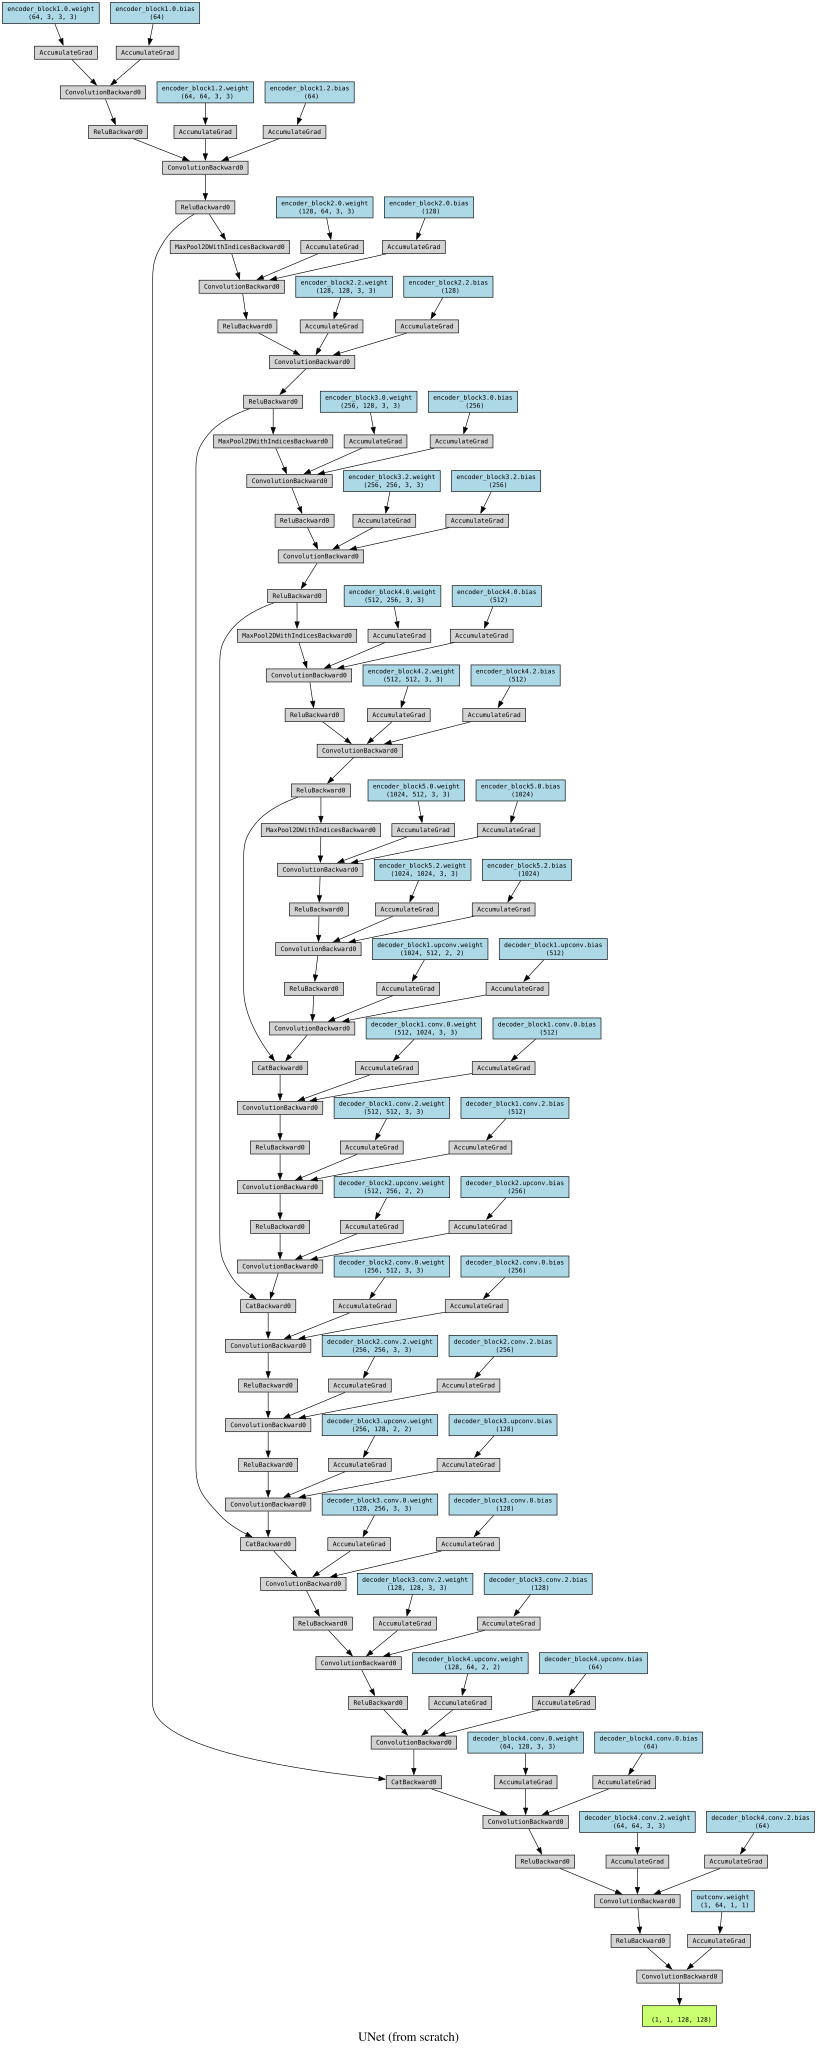

In [5]:
x = torch.randn(1, 3, 128, 128)

y_unet = unet(x)
dot_unet = make_dot(y_unet, params=dict(unet.named_parameters()), show_attrs=False, show_saved=False)
dot_unet.attr(label="UNet (from scratch)", fontsize="20")
dot_unet

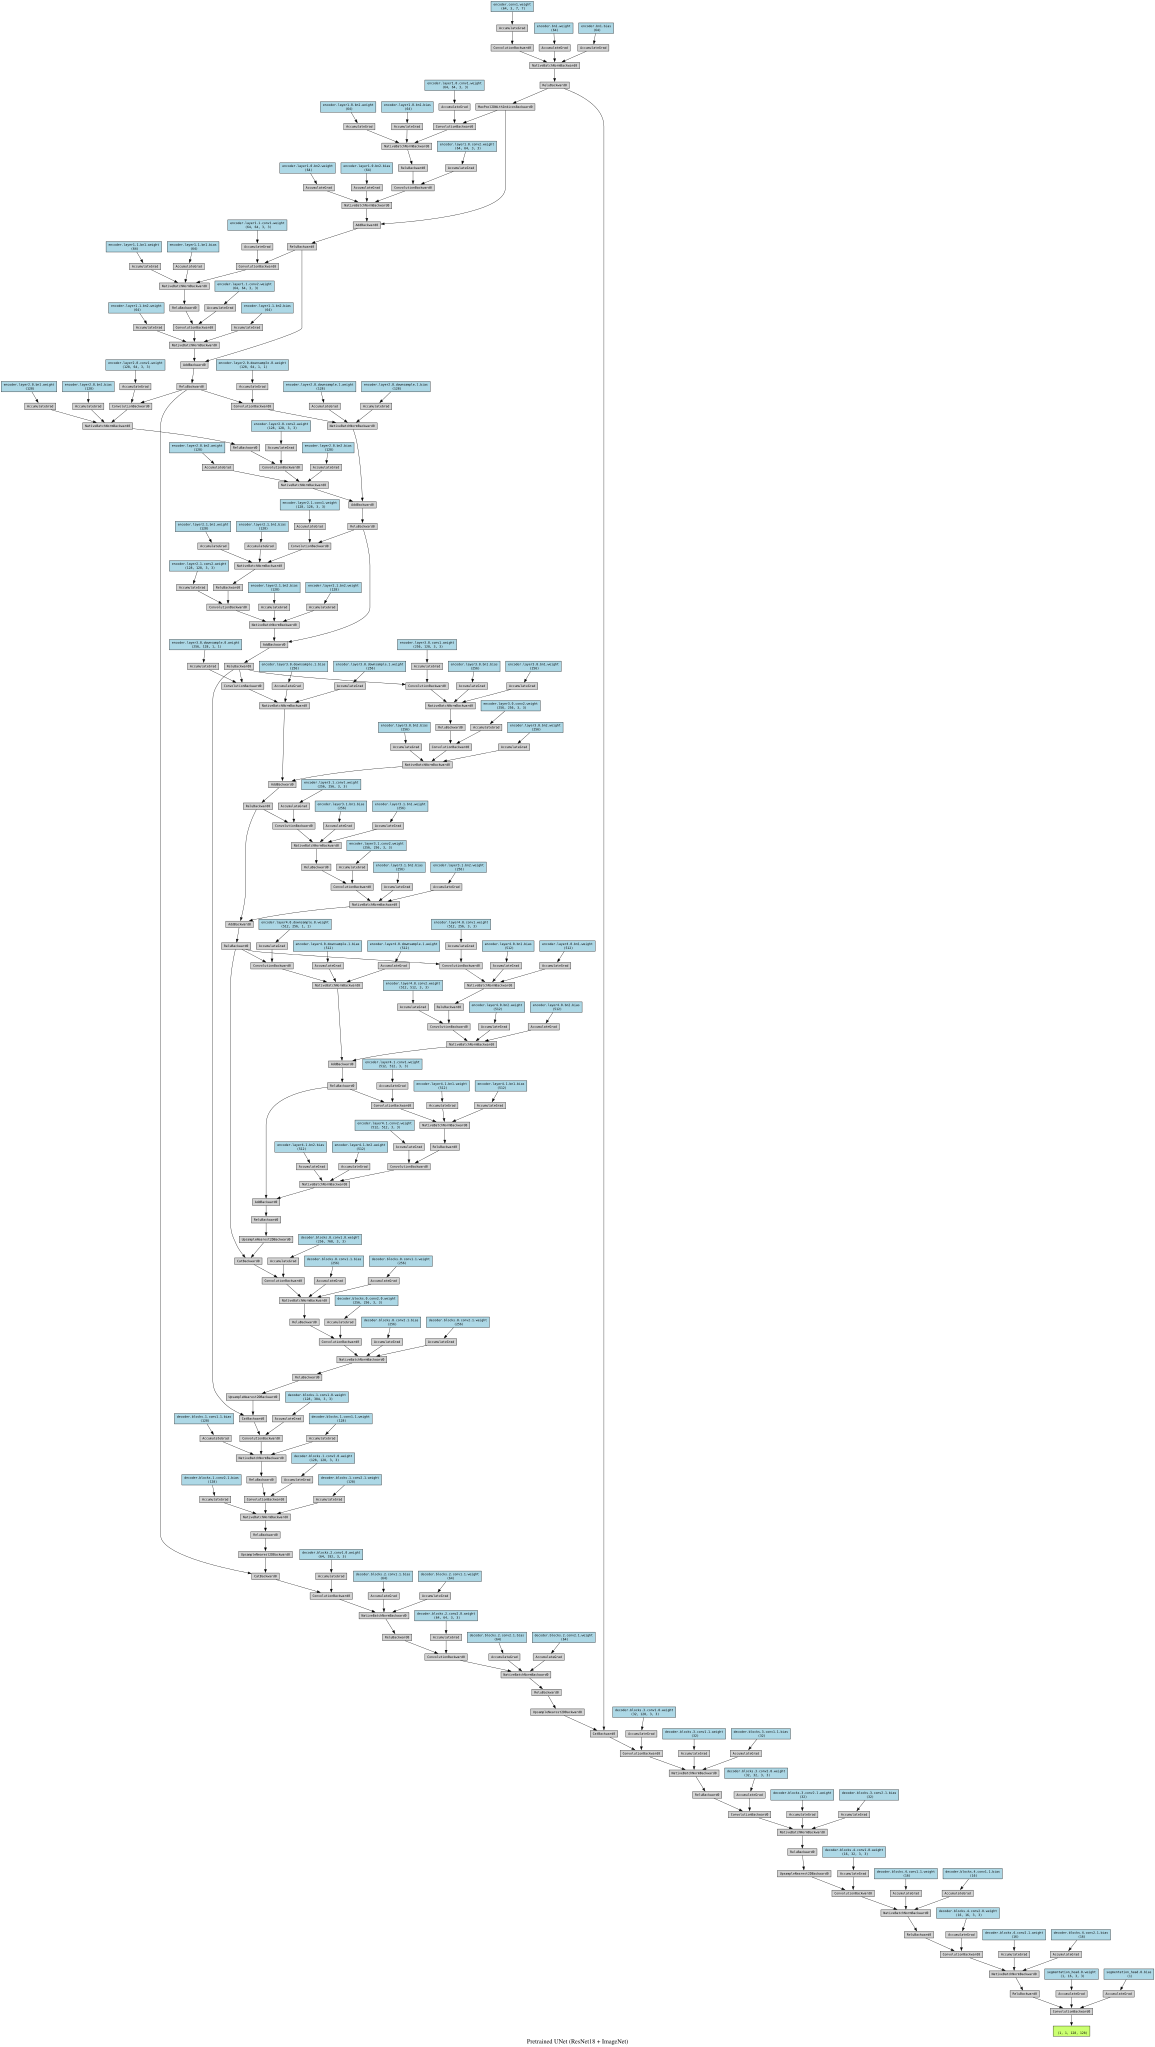

In [6]:
y_pretrained = pretrained(x)
dot_pretrained = make_dot(y_pretrained, params=dict(pretrained.named_parameters()), show_attrs=False, show_saved=False)
dot_pretrained.attr(label="Pretrained UNet (ResNet18 + ImageNet)", fontsize="20")
dot_pretrained

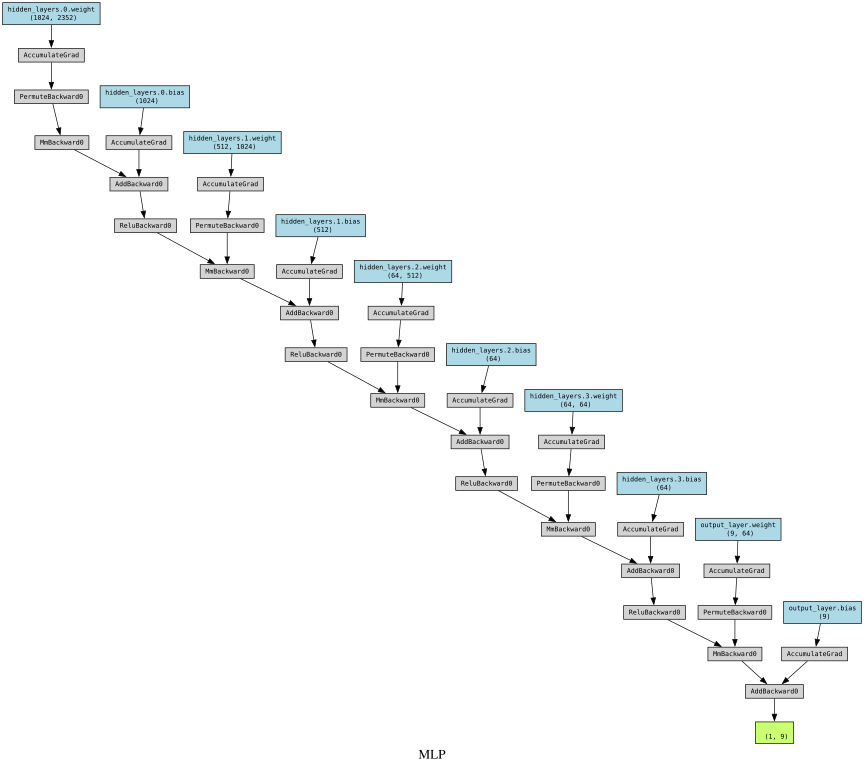

In [26]:
x_mlp = torch.randn(1, 3, 28, 28)
y_mlp = mlp(x_mlp)
dot_mlp = make_dot(y_mlp, params=dict(mlp.named_parameters()), show_attrs=False, show_saved=False)
dot_mlp.attr(label="MLP", fontsize="20")
dot_mlp

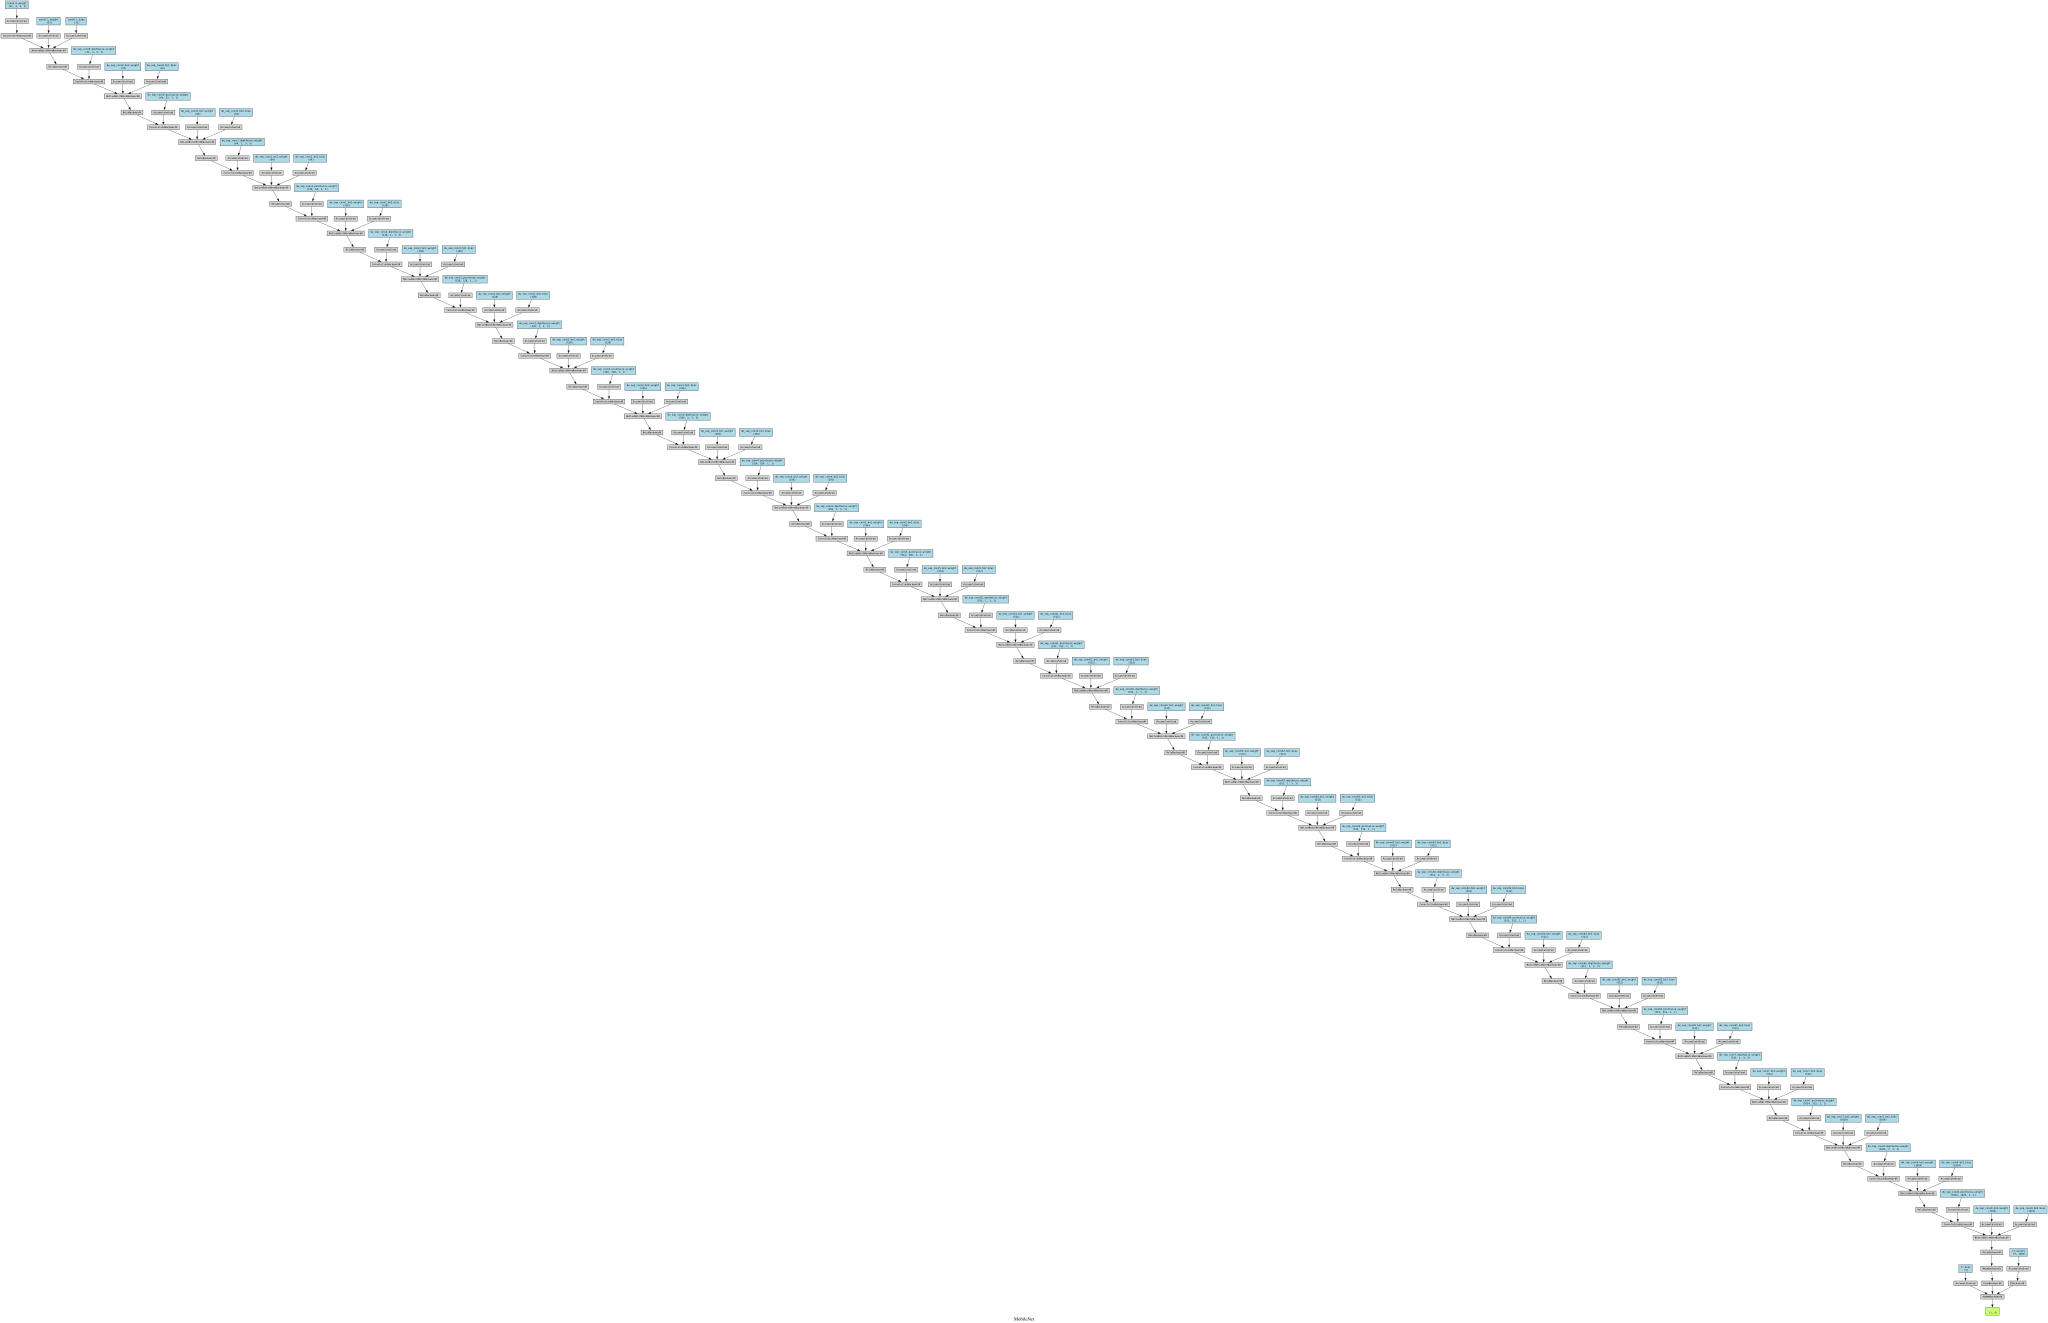

In [27]:
x_mn = torch.randn(1, 3, 224, 224)
y_mn = mobilenet(x_mn)
dot_mn = make_dot(y_mn, params=dict(mobilenet.named_parameters()), show_attrs=False, show_saved=False)
dot_mn.attr(label="MobileNet", fontsize="20")
dot_mn

## torchview — Module-Level Graphs

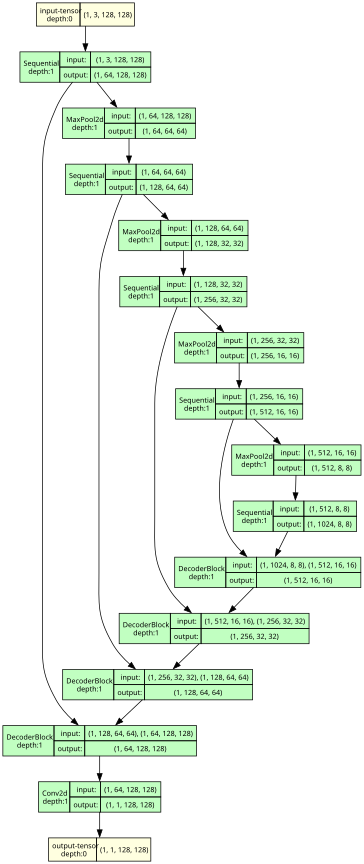

In [14]:
graph_unet = draw_graph(unet, input_size=(1, 3, 128, 128), depth=1, expand_nested=True)
graph_unet.visual_graph

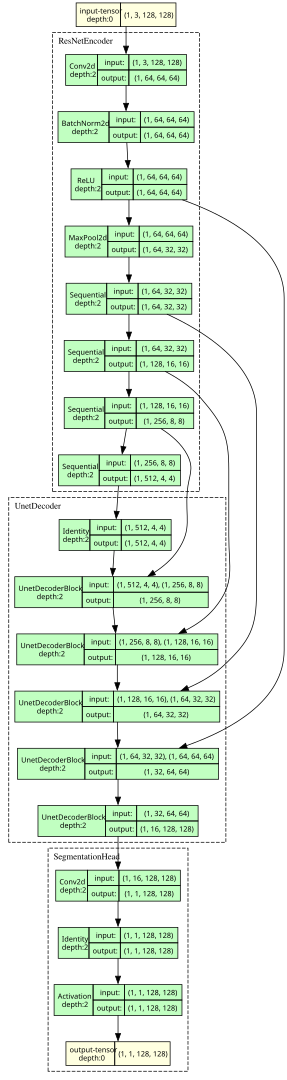

In [16]:
graph_pretrained = draw_graph(pretrained, input_size=(1, 3, 128, 128), depth=2, expand_nested=True)
graph_pretrained.visual_graph

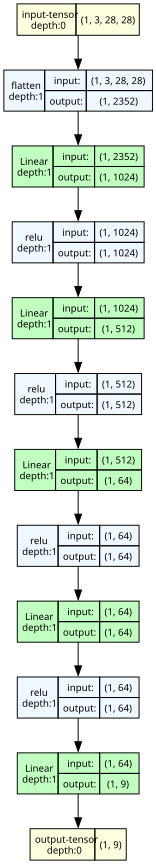

In [30]:
graph_mlp = draw_graph(mlp, input_size=(1, 3, 28, 28), depth=1, expand_nested=False)
graph_mlp.visual_graph

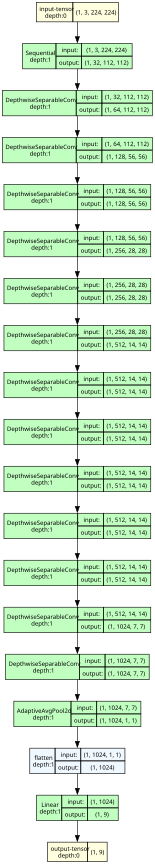

In [35]:
graph_mn = draw_graph(mobilenet, input_size=(1, 3, 224, 224), depth=1, expand_nested=True)
graph_mn.visual_graph